# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          
Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [ ]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [ ]:
# esempi di lambda function

f = lambda x: x**2
g = lambda t: t**3
h = lambda t,x,y: t+x+y

print("valuto la funzione f in 0.5: %f" % f(0.5))
print("valuto la funzione g in 0.5: %f" % g(0.5))
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 0.250000
valuto la funzione g in 0.5: 0.125000
valuto la funzione h in (1,2,3): 6.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [ ]:
# lambda function della funzione f

f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1


Rappresentazione grafica

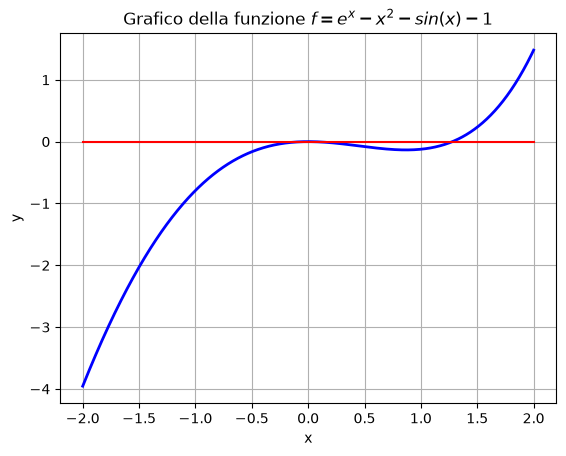

In [ ]:
# rappresentazione grafica della funzione f

xgrid = np.linspace(-2,2,1000)
plt.plot(xgrid, f(xgrid), 'b-',  linewidth=2)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r-')
# oppure plt.plot([-2,2], [0,0])
plt.title("Grafico della funzione $f = e^x - x^2 - sin(x) - 1$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Risposta:**</mark></br>
No, il metodo di bisezione non è adatto al calcolo della radice in (0,0), siccome nell'intorno di quel punto la funzione non cambia segno (f(a)*f(b)>0) e questo non soddisfa i requisiti del teorema degli zeri.

<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [ ]:
# definzione del metodo di bisezione
def bisez(f, a, b, toll):

  if (f(a)*f(b)>=0):
    raise RuntimeError("Errore: a e b non è un intervallo valido") # blocca la funzione

  xvect = [] # creo una lista vuota

  while (abs(b-a) > toll):
    x = 0.5*(a+b) # calcolo il punto medio

    if (f(x)==0):
      xvect.append(x)
      print("x è uno zero")
      break
    
    if (f(a)*f(x)<0):
      b = x
    else:
      a = x
    xvect.append(x)
  
  return np.array(xvect)

<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [ ]:
# scelta degli estremi a,b
a = 1
b = 1.5
toll = 1e-12
xvect = bisez(f, a, b, toll)
x0 = (xvect[-1])

# stampare il numero di iterazioni effettuato, il valore di x0 e valore di f(x0)
print("Numero iterazioni: %d." % len(xvect))
print("Ultimo valore di x: %f." % x0)
print("Ultimo valore di f: %e." % f(x0))

Numero iterazioni: 39.
Ultimo valore di x: 1.279701.
Ultimo valore di f: 6.681322e-13.


**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Risposta:**</mark></br>
Il metodo di Newton converge solo localmente, cioè nell'intorno di una soluzione esatta: la scelta del primo valore di tentativo influisce sulla convergenza o mancata tale. In questo caso, il metodo può essere applicato per individuare entrambi gli zeri.

<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazioni
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [ ]:
# definizione del metodo di newton
def newton(f, df, x0, nmax, toll):

  # inizializzazione del vettore delle iterazioni
  xvect =[]
  xold = x0

  # ciclo iterativo
  for nit in range(nmax):

    if (df(xold)==0):
      raise RuntimeError("La derivata prima nel punto %f è uguale a zero" % xold)

    if (f(xold)==0):
      xvect.append(xold)
      print("%f è uno zero" % xold)
      break

    # passo iterativo
    xnew = xold - f(xold)/df(xold)
    # carico i vettori
    xvect.append(xnew)
    # criterio di arresto e aggiornamento
    if(abs(xnew-xold)<toll):
      break
    else:
      xold = xnew

  return np.array(xvect)

<mark>**Esercizio 2.2: modifica di Newton**</mark></br>
Si scriva, modificando opportunamente la function $\verb|newton|$,
il metodo di Newton modificato, passando come parametro in ingresso anche la molteplicità dello zero cercato. L'intestazione della funzione sarà la seguente:


      def newton (f,df,x0,nmax,toll,m=1)
        #
        # modificare il passo iterativo di newton
        #  x^{k+1} = x^k - m f(x^k)/f'(x^k)
        #
        return xvect

dove $\verb|m|$ è la molteplicità dello zero cercato.
Impostando m=1, se l'input non viene inserito il metodo funziona come quello semplice.

In [ ]:
# definizione del metodo di newton modificato
def newton(f, df, x0, nmax, toll, m=1):

  # inizializzazione del vettore delle iterazioni
  xvect =[]
  xold = x0

  # ciclo iterativo
  for nit in range(nmax):

    if (df(xold)==0):
      raise RuntimeError("La derivata prima nel punto %f è uguale a zero" % xold)

    if (f(xold)==0):
      xvect.append(xold)
      print("%f è uno zero" % xold)
      break

    # passo iterativo
    xnew = xold - m*f(xold)/df(xold)
    # carico i vettori
    xvect.append(xnew)
    # criterio di arresto e aggiornamento
    if(abs(xnew-xold)<toll):
      break
    else:
      xold = xnew

  return np.array(xvect)

<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


In [ ]:
# funzione f e la sua derivata df
f = lambda t: np.exp(t) - t**2 - np.sin(t) - 1.0
df = lambda t: np.exp(t) - 2*t - np.cos(t)

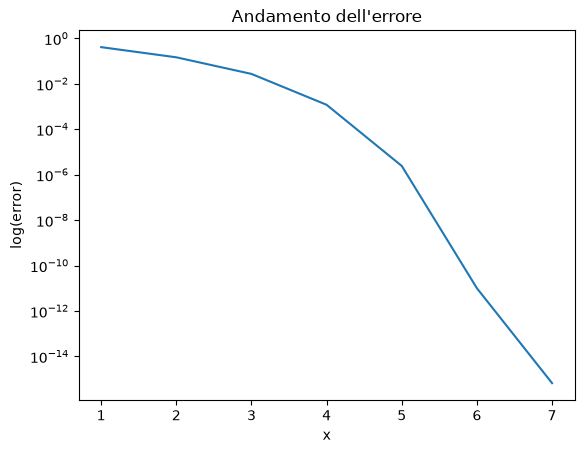

In [ ]:
# ricerca dello zero xe=1.279701331000996
xe=1.279701331000996
# starting point
x0=1

xvect = newton(f, df, x0, 100, 1e-6)
    
# calcolo dell'errore
error = np.abs(xe-xvect)

# rappresentazione grafica dell'errore usando plt.semilogy()
plt.semilogy(np.arange(1,len(xvect)+1),error)
plt.xlabel("x")
plt.ylabel("log(error)")
plt.title("Andamento dell'errore")
plt.show()

-0.000000 è uno zero


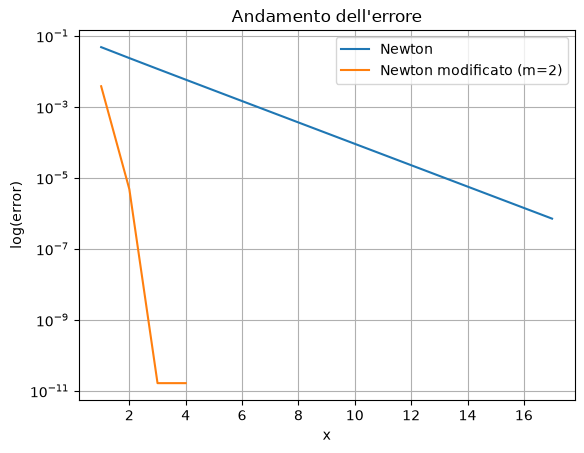

In [ ]:
# Ricerca dello zero xe=0
xe=0
# starting point
x0=0.1

xvect = newton(f, df, x0, 100, 1e-6)

xvectm = newton(f, df, x0, 100, 1e-6, 2)

# calcolo dell'errore
error = np.abs(xe-xvect)
errorm = np.abs(xe-xvectm)

# rappresentazione grafica dell'errore usando plt.semilogy()
plt.semilogy(np.arange(1,len(xvect)+1),error)
plt.semilogy(np.arange(1,len(xvectm)+1),errorm)
plt.legend(["Newton", "Newton modificato (m=2)"])
plt.xlabel("x")
plt.ylabel("log(error)")
plt.title("Andamento dell'errore")
plt.grid()
plt.show()

Il metodo modificato converge molto più velocemente.

**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

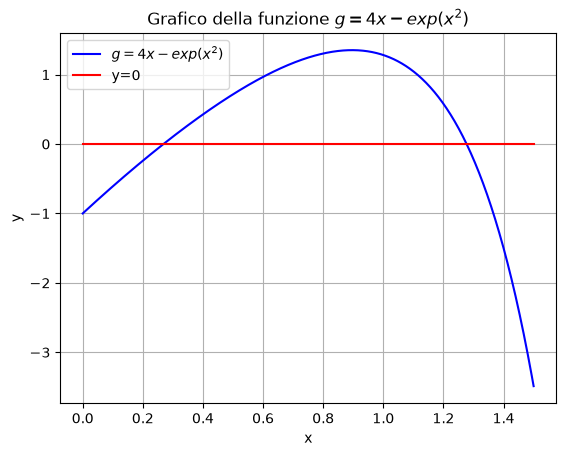

In [ ]:
# plot della funzione g

g = lambda x : 4*x - np.exp(x**2)

xgrid = np.linspace(0,1.5,1000)
plt.plot(xgrid, g(xgrid), 'b-', label="$g = 4x - exp(x^2)$")
plt.plot([0,1.5], [0,0], 'r-', label="y=0")
plt.legend()
plt.title("Grafico della funzione $g = 4x - exp(x^2)$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()


**Osservazione sulle soluzioni dell'esercizio 3.1:**

Dal grafico si osserva che la funzione g ha due soluzioni e sono contenute negli intervalli (0.2, 0.4) e (1.2, 1.4).

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

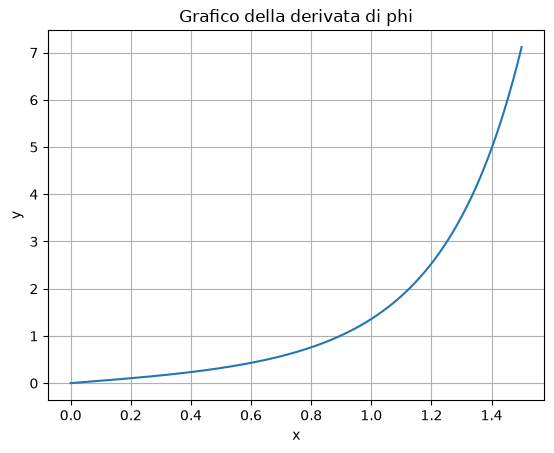

In [ ]:
# plot della derivata prima di phi

phi = lambda t : np.exp(t**2)/4
dphi = lambda t : t*np.exp(t**2)/2

plt.plot(xgrid, dphi(xgrid))
plt.title("Grafico della derivata di phi")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()


**Motivazione esercizio 3.2:**

La funzione 𝜙 è continua e derivabile in ogni intorno dei suoi due punti fissi, che coincidono con gli zeri di g.

Nell'intervallo (0.2, 0.4) il modulo della derivata della funzione è minore di 1, quindi valgono le ipotesi del teorema di convergenza del metodo di punto fisso.

Invece, nell'intervallo (1.2, 1.4) il modulo della derivata della funzione è maggiore o uguale a 1 e il metodo potrebbe non convergere.

<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [ ]:
def puntofisso(phi, x0, nmax, toll):

  xvect = [] # inizializzo il vettore delle iterazioni
  xold = x0

  for nit in range(nmax):

    xnew = phi(xold) # passo iterativo
    xvect.append(xnew)

    # criterio di arresto
    if(abs(xnew-xold)<toll):
      break
    else:
      xold = xnew

  return np.array(xvect)

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo del punto fisso, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [ ]:
# verifica del metodo di punto fisso

for x0 in [0, 1.5]:
    xvect = puntofisso(phi, x0, 100, 1e-5)
    print("Dato iniziale: %f." %x0)
    print("Numero iterazioni: %d." % len(xvect))
    print("Radice trovata: %f.\n" % xvect[-1])

Dato iniziale: 0.000000.
Numero iterazioni: 6.
Radice trovata: 0.268719.

Dato iniziale: 1.500000.
Numero iterazioni: 100.
Radice trovata: inf.



/var/folders/d5/tstwk7wd0k12815lzrj7kpdw0000gn/T/ipykernel_8273/85985159.py:3: RuntimeWarning: overflow encountered in exp
  phi = lambda t : np.exp(t**2)/4
/var/folders/d5/tstwk7wd0k12815lzrj7kpdw0000gn/T/ipykernel_8273/3001667893.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  if(abs(xnew-xold)<toll):


## **Bisezione**

<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [ ]:
def bisezfor(f, a, b, toll):

  if (f(a)*f(b)>=0):
    raise RuntimeError("Errore: a e b non è un intervallo valido") # blocca la funzione

  nmax = np.fix(np.log2(abs(b-a)/toll)-1)+1
  xvect = [] # creo una lista vuota

  for nit in range(int(nmax)):
    x = 0.5*(a+b) # calcolo il punto medio

    if (f(x)==0):
      xvect.append(x)
      print("x è uno zero della funzione")
      break
    
    if (f(a)*f(x)<0):
      b = x
    else:
      a = x
    xvect.append(x)


  return np.array(xvect)


<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [ ]:
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
# scelta degli estremi a,b
a = 1
b = 1.5
toll = 1e-12

# stampare iterazioni, valore di x* e valore di f(x*)
xvect = bisezfor(f,a,b,toll)
print("Numero iterazioni: %d." % len(xvect))
print("Radice trovata: %f." %xvect[-1])
print("Ultimo valore di f: %.e\n" %f(xvect[-1]))


Numero iterazioni: 38.
Radice trovata: 1.279701.
Ultimo valore di f: 1e-12



/var/folders/d5/tstwk7wd0k12815lzrj7kpdw0000gn/T/ipykernel_8273/3529571667.py:6: DeprecationWarning: numpy.fix is deprecated. Use numpy.trunc instead, which is faster and follows the Array API standard.
  nmax = np.fix(np.log2(abs(b-a)/toll)-1)+1


## **Bisezione e Newton**
<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.



In [ ]:
# estremi dell'intervallo
a=1
b=1.5
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)

nmax_b = 5
toll_b = 1.e-3

nmax_n = 100
toll_n = 1e-10

xvect_b = bisez(f,a,b,toll_b)
xvect_n = newton(f,df,xvect_b[nmax_b-1],nmax_n,toll_n)
xvect = np.concatenate([xvect_b[0:nmax_b], xvect_n])

x = xvect[-1]
print("Numero di iterazioni: %d." %len(xvect))
print("Ultimo valore di x: %1.10f." %x)
print("Ultimo valore di f: %.e.\n" %f(x))



Numero di iterazioni: 9.
Ultimo valore di x: 1.2797013310.
Ultimo valore di f: -3e-16.

